# SoftCAM-Transformer v3 — Analyse H1 (Run B5)

Charge le checkpoint de Run B5 et teste systématiquement les hypothèses
**H1.A**, **H1.B**, **H1.D**, **H1.E**, **H1.F**, **H1.G**.

| Hypothèse | Question | Test |
|-----------|----------|------|
| H1.A | M pointe les heures du profil journalier C4 ? | Argmax → time-of-day |
| H1.B | M et `cross_attentions` du décodeur convergent ? | Argmax comparison |
| H1.C ✅ | SoftCAM ne dégrade pas la précision ? | **PASSÉ (B5 : R²=0.6628, Spearman=0.9222)** |
| H1.D | Cartes M cohérentes entre les 5 fonctions ? | Pearson entre M moyennes |
| H1.E | M discrimine 953 (best) de 949 (worst) ? | Entropy comparison |
| H1.F | Masquer top-k de M dégrade la prédiction ? | Comprehensiveness curve |
| H1.G | Garder seulement top-k de M préserve la prédiction ? | Sufficiency curve |

**Note importante (ceiling effect)** : à mix=0.05, h_evidence contribue 5%
de la prédiction architecturalement. H1.F et H1.G mesurent donc la fidélité
*à l'intérieur de la branche evidence*, pas sur le modèle entier.

> Avant de lancer : Runtime → Change runtime type → **T4 GPU**.


## 1 — Setup

In [1]:
import subprocess
gpu = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(gpu.stdout if gpu.returncode == 0 else 'Pas de GPU — vérifier le runtime.')

Tue May 19 01:10:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%%capture
!pip install -q transformers datasets "gluonts[torch]" accelerate evaluate scipy scikit-learn tqdm openpyxl ujson

## 2 — Récupération du code

In [3]:
import os, sys

REPO_URL = 'https://github.com/theblackmamba08/recherche-m2-xai-faas.git'
REPO_DIR = '/content/recherche-m2-xai-faas'

ipy = get_ipython()
if not os.path.isdir(REPO_DIR):
    ipy.system(f'git clone {REPO_URL} {REPO_DIR}')
else:
    ipy.system(f'git -C {REPO_DIR} pull')

if f'{REPO_DIR}/code' not in sys.path:
    sys.path.insert(0, f'{REPO_DIR}/code')

models_dir = f'{REPO_DIR}/code/src/models'
if not os.path.isdir(models_dir):
    raise FileNotFoundError(
        f'{models_dir} introuvable.\n'
        'Essaie : Runtime → Disconnect and delete runtime, puis relance.'
    )
print('Repo prêt :', os.listdir(models_dir))

Cloning into '/content/recherche-m2-xai-faas'...
remote: Enumerating objects: 677, done.
remote: Counting objects: 100% (543/543), done.
remote: Compressing objects: 100% (312/312), done.
remote: Total 677 (delta 362), reused 409 (delta 229), pack-reused 134 (from 1)
Receiving objects: 100% (677/677), 73.35 MiB | 32.21 MiB/s, done.
Resolving deltas: 100% (384/384), done.
Repo prêt : ['softcam_transformer_v3.py', 'softcam_transformer_v2.py', '__init__.py', 'softcam_transformer.py']


## 3 — Imports, seed, config (identiques B5)

In [4]:
import random, json, gc
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from functools import lru_cache, partial
from pathlib import Path
from tqdm.notebook import tqdm

SEED = 998
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4


In [5]:
# ── Hyperparams (identiques B5) ────────────────────────────────
FREQ              = '1T'
PREDICTION_LENGTH = 120
CONTEXT_LENGTH    = 240
D_MODEL           = 32
N_HEADS           = 2
ENCODER_LAYERS    = 4
DECODER_LAYERS    = 4
EMBEDDING_DIM     = [2]
DROPOUT           = 0.1
BATCH_SIZE_TEST   = 64

# ── Evidence Layer v3 (état final B5) ──
USE_EVIDENCE_LAYER   = True
EVIDENCE_MIX_TARGET  = 0.05
ALPHA_L1             = 0.0
BETA_L2              = 1e-3
GAMMA_ENTROPY_TARGET = 1e-3

CLUSTER_ID = 4
SOURCE_RUN = 'softcam-cluster4-v3-runB5'
RUN_NAME   = 'softcam-cluster4-v3-h1-analysis'

# B5 reference metrics
B5_R2, B5_SPEAR = 0.6628, 0.9222

print(f'Source run : {SOURCE_RUN}')
print(f'Analysis   : {RUN_NAME}')
print(f'Reference  : R²={B5_R2}  Spearman={B5_SPEAR}')

Source run : softcam-cluster4-v3-runB5
Analysis   : softcam-cluster4-v3-h1-analysis
Reference  : R²=0.6628  Spearman=0.9222


## 4 — Google Drive + localisation du checkpoint B5

In [6]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE_SRC = f'/content/drive/MyDrive/m2-xai-faas/experiments/{SOURCE_RUN}'
DRIVE_BASE     = f'/content/drive/MyDrive/m2-xai-faas/experiments/{RUN_NAME}'

for subdir in ['results', 'figures', 'evidence_maps']:
    os.makedirs(f'{DRIVE_BASE}/{subdir}', exist_ok=True)

ckpt_path = f'{DRIVE_BASE_SRC}/checkpoints/v3_runB5_final.pt'
assert os.path.exists(ckpt_path), (
    f'Checkpoint B5 introuvable : {ckpt_path}\n'
    f'Vérifie que Run B5 a bien été exécuté et que le checkpoint a été sauvegardé.'
)
print(f'Checkpoint trouvé : {ckpt_path}')
print(f'Taille : {os.path.getsize(ckpt_path) / 1e6:.1f} MB')

Mounted at /content/drive
Checkpoint trouvé : /content/drive/MyDrive/m2-xai-faas/experiments/softcam-cluster4-v3-runB5/checkpoints/v3_runB5_final.pt
Taille : 0.5 MB


## 5 — Chargement Cluster 4

In [7]:
from datasets import Dataset

try:
    from google.colab import drive as _drive  # noqa: F401
    DATA_DIR = Path('/content/drive/MyDrive/Recherche/Datasets')
except ImportError:
    DATA_DIR = Path('../../memoire/06-datasets/raw').resolve()

START_DATE = '2021-01-01 00:00:00'

df = pd.read_csv(DATA_DIR / f'cluster_{CLUSTER_ID}.csv', index_col='Function')
all_series = []
for func_id, row in df.iterrows():
    all_series.append({
        'function_id': int(func_id),
        'cluster':     CLUSTER_ID,
        'target_full': row.values.astype(np.float32),
    })

print(f'Cluster {CLUSTER_ID} — {len(all_series)} fonctions :')
for s in all_series:
    print(f"  function_id={s['function_id']}  longueur={len(s['target_full'])}")

train_rows, test_rows = [], []
for ts_idx, s in enumerate(all_series):
    base = {'start': START_DATE, 'feat_static_cat': [ts_idx],
            'cluster': s['cluster'], 'function_id': s['function_id']}
    train_rows.append({**base, 'target': s['target_full'][:-PREDICTION_LENGTH].tolist()})
    test_rows.append( {**base, 'target': s['target_full'].tolist()})

train_dataset = Dataset.from_list(train_rows)
test_dataset  = Dataset.from_list(test_rows)
print(f'\nDatasets : train={len(train_dataset)}  test={len(test_dataset)}')

Cluster 4 — 5 fonctions :
  function_id=949  longueur=20160
  function_id=951  longueur=20160
  function_id=952  longueur=20160
  function_id=953  longueur=20160
  function_id=954  longueur=20160

Datasets : train=5  test=5


## 6 — Pipeline GluonTS (identique B5)

In [8]:
from gluonts.time_feature import get_lags_for_frequency, time_features_from_frequency_str
from gluonts.dataset.field_names import FieldName
from gluonts.transform import (
    AddAgeFeature, AddObservedValuesIndicator, AddTimeFeatures,
    AsNumpyArray, Chain, ExpectedNumInstanceSampler, InstanceSplitter,
    RemoveFields, TestSplitSampler, ValidationSplitSampler,
    VstackFeatures, RenameFields,
)
from gluonts.itertools import Cyclic, Cached
from gluonts.dataset.loader import as_stacked_batches

lags_sequence = get_lags_for_frequency(FREQ)
time_features  = time_features_from_frequency_str(FREQ)

@lru_cache(10_000)
def convert_to_pandas_period(date, freq):
    return pd.Period(date, freq)

def transform_start_field(batch, freq):
    batch['start'] = [convert_to_pandas_period(d, freq) for d in batch['start']]
    return batch

for ds in (train_dataset, test_dataset):
    ds.set_transform(partial(transform_start_field, freq=FREQ))

def create_transformation(freq, config):
    remove_field_names = []
    if config.num_static_real_features == 0:
        remove_field_names.append(FieldName.FEAT_STATIC_REAL)
    if config.num_dynamic_real_features == 0:
        remove_field_names.append(FieldName.FEAT_DYNAMIC_REAL)
    if config.num_static_categorical_features == 0:
        remove_field_names.append(FieldName.FEAT_STATIC_CAT)
    return Chain(
        [RemoveFields(field_names=remove_field_names)]
        + ([AsNumpyArray(field=FieldName.FEAT_STATIC_CAT, expected_ndim=1, dtype=int)]
           if config.num_static_categorical_features > 0 else [])
        + [AsNumpyArray(field=FieldName.TARGET, expected_ndim=1),
           AddObservedValuesIndicator(target_field=FieldName.TARGET,
                                      output_field=FieldName.OBSERVED_VALUES),
           AddTimeFeatures(start_field=FieldName.START, target_field=FieldName.TARGET,
                           output_field=FieldName.FEAT_TIME,
                           time_features=time_features_from_frequency_str(freq),
                           pred_length=config.prediction_length),
           AddAgeFeature(target_field=FieldName.TARGET, output_field=FieldName.FEAT_AGE,
                         pred_length=config.prediction_length, log_scale=True),
           VstackFeatures(output_field=FieldName.FEAT_TIME,
                          input_fields=[FieldName.FEAT_TIME, FieldName.FEAT_AGE]),
           RenameFields(mapping={
               FieldName.FEAT_STATIC_CAT: 'static_categorical_features',
               FieldName.FEAT_TIME:       'time_features',
               FieldName.TARGET:          'values',
               FieldName.OBSERVED_VALUES: 'observed_mask',
           })]
    )

def create_instance_splitter(config, mode):
    sampler = {
        'train':      ExpectedNumInstanceSampler(num_instances=1.0,
                                                  min_future=config.prediction_length),
        'validation': ValidationSplitSampler(min_future=config.prediction_length),
        'test':       TestSplitSampler(),
    }[mode]
    return InstanceSplitter(
        target_field='values', is_pad_field=FieldName.IS_PAD,
        start_field=FieldName.START, forecast_start_field=FieldName.FORECAST_START,
        instance_sampler=sampler,
        past_length=config.context_length + max(config.lags_sequence),
        future_length=config.prediction_length,
        time_series_fields=['time_features', 'observed_mask'],
    )

def _pred_fields(config):
    f = ['past_time_features', 'past_values', 'past_observed_mask', 'future_time_features']
    if config.num_static_categorical_features > 0:
        f.append('static_categorical_features')
    return f

def create_backtest_dataloader(config, freq, data, batch_size):
    tr = create_transformation(freq, config)
    sp = create_instance_splitter(config, 'validation')
    return as_stacked_batches(sp.apply(tr.apply(data), is_train=True),
                              batch_size=batch_size, output_type=torch.tensor,
                              field_names=_pred_fields(config))

print('Pipeline GluonTS prête.')

Pipeline GluonTS prête.


/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/lag.py:104: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)
/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


## 7 — Construction du modèle v3 + chargement checkpoint B5

In [9]:
from src.models.softcam_transformer_v3 import (
    SoftCAMTransformerV3Config,
    SoftCAMTransformerV3ForPrediction,
)

cfg = SoftCAMTransformerV3Config(
    prediction_length=PREDICTION_LENGTH,
    context_length=CONTEXT_LENGTH,
    lags_sequence=lags_sequence,
    num_time_features=len(time_features) + 1,
    num_static_categorical_features=1,
    cardinality=[len(train_dataset)],
    embedding_dimension=EMBEDDING_DIM,
    encoder_layers=ENCODER_LAYERS,
    decoder_layers=DECODER_LAYERS,
    d_model=D_MODEL,
    encoder_attention_heads=N_HEADS,
    decoder_attention_heads=N_HEADS,
    encoder_ffn_dim=max(D_MODEL, 32),
    decoder_ffn_dim=max(D_MODEL, 32),
    dropout=DROPOUT,
    use_evidence_layer=USE_EVIDENCE_LAYER,
    evidence_mix=EVIDENCE_MIX_TARGET,
    alpha_l1=ALPHA_L1,
    beta_l2=BETA_L2,
    gamma_entropy=GAMMA_ENTROPY_TARGET,
)

model = SoftCAMTransformerV3ForPrediction(cfg).to(device)

ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
missing, unexpected = model.load_state_dict(ckpt['model'], strict=False)
print(f'Checkpoint chargé.')
print(f'  Missing keys    : {len(missing)} (premier: {missing[0] if missing else "—"})')
print(f'  Unexpected keys : {len(unexpected)} (premier: {unexpected[0] if unexpected else "—"})')
model.eval()
model.evidence_mix  = EVIDENCE_MIX_TARGET
model.gamma_entropy = GAMMA_ENTROPY_TARGET
print(f'Mode eval. mix={model.evidence_mix}  γ={model.gamma_entropy:.0e}')

Checkpoint chargé.
  Missing keys    : 0 (premier: —)
  Unexpected keys : 0 (premier: —)
Mode eval. mix=0.05  γ=1e-03


## 8 — Sanity check : reproduit-on R²=0.6628 ?

On évalue le modèle chargé sur le test set avec le même protocole que B5
(generate, médiane sur 100 trajectoires). Si on retrouve R²≈0.66, le
checkpoint est intact.


In [10]:
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

@torch.no_grad()
def evaluate_generate(model, dataloader, dataset, config, device, prefix=''):
    model.eval()
    forecasts = []
    for b in dataloader:
        out = model.generate(
            static_categorical_features=b['static_categorical_features'].to(device)
                if config.num_static_categorical_features > 0 else None,
            past_time_features=b['past_time_features'].to(device),
            past_values=b['past_values'].to(device),
            future_time_features=b['future_time_features'].to(device),
            past_observed_mask=b['past_observed_mask'].to(device),
        )
        forecasts.append(out.sequences.cpu().numpy())
    forecasts = np.vstack(forecasts)
    forecast_median = np.median(forecasts, axis=1)

    r2s, spears = [], []
    for ts_idx in range(len(dataset)):
        target = np.array(dataset[ts_idx]['target'])
        actual = target[-config.prediction_length:]
        pred   = forecast_median[ts_idx]
        r2s.append(r2_score(actual, pred))
        rho, _ = spearmanr(actual, pred)
        spears.append(rho)
    r2 = float(np.mean(r2s)); spear = float(np.mean(spears))
    if prefix:
        print(f'{prefix}  R²={r2:.4f}  Spearman={spear:.4f}')
        print(f'  per-series R²       : {[f"{x:.3f}" for x in r2s]}')
        print(f'  per-series Spearman : {[f"{x:.3f}" for x in spears]}')
    return r2, spear, r2s, spears

test_loader = create_backtest_dataloader(cfg, FREQ, test_dataset, BATCH_SIZE_TEST)
sanity_r2, sanity_spear, sanity_r2s, sanity_spears = evaluate_generate(
    model, test_loader, test_dataset, cfg, device, prefix='SANITY'
)

delta_r2    = (sanity_r2    - B5_R2)    * 100
delta_spear = (sanity_spear - B5_SPEAR) * 100
print(f'\nΔ vs B5 : R²={delta_r2:+.2f} pp   Spearman={delta_spear:+.2f} pp')
sanity_ok = abs(delta_r2) < 5.0 and abs(delta_spear) < 5.0
print(f'Sanity check : {"OK ✅" if sanity_ok else "DIVERGE ⚠️"}')

/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)
/tmp/ipykernel_616/1582339498.py:17: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  return pd.Period(date, freq)


SANITY  R²=0.6646  Spearman=0.9188
  per-series R²       : ['0.571', '0.655', '0.779', '0.589', '0.728']
  per-series Spearman : ['0.955', '0.961', '0.894', '0.890', '0.893']

Δ vs B5 : R²=+0.18 pp   Spearman=-0.34 pp
Sanity check : OK ✅


## 9 — Extraction des cartes M (teacher-forced) + sauvegarde

Pour chaque fonction du cluster, on fait un forward teacher-forced (en
fournissant ``future_values``) et on récupère la matrice M de shape
``(prediction_length=120, context_length=240)``.


In [11]:
test_loader_expl = create_backtest_dataloader(cfg, FREQ, test_dataset, batch_size=1)
evidence_maps = []      # liste de (func_id, M_numpy, batch_dict)
batches_cache = []      # cache des batches pour réutilisation H1.F/H1.G

model.eval()
with torch.no_grad():
    for ts_idx, b in enumerate(test_loader_expl):
        func_id = test_dataset[ts_idx]['function_id']
        target_full = np.array(test_dataset[ts_idx]['target'])
        future_vals = torch.tensor(
            target_full[-PREDICTION_LENGTH:], dtype=torch.float32
        ).unsqueeze(0).to(device)
        future_obs = torch.ones_like(future_vals)

        M = model.explain(
            past_values=b['past_values'].to(device),
            past_time_features=b['past_time_features'].to(device),
            past_observed_mask=b['past_observed_mask'].to(device),
            future_values=future_vals,
            future_time_features=b['future_time_features'].to(device),
            static_categorical_features=b['static_categorical_features'].to(device)
                if cfg.num_static_categorical_features > 0 else None,
            future_observed_mask=future_obs,
        )
        M_np = M.squeeze(0).cpu().numpy()  # (T, ctx)
        evidence_maps.append((func_id, M_np))
        batches_cache.append((func_id, {k: v for k, v in b.items()}, future_vals, future_obs))

        np.save(f'{DRIVE_BASE}/evidence_maps/M_func{func_id}.npy', M_np)
        print(f'  func_id={func_id}  M.shape={M_np.shape}  '
              f'argmax_mean={int(M_np.argmax(axis=1).mean())}  '
              f'max_weight={M_np.max():.4f}  '
              f'entropy={-(M_np * np.log(M_np.clip(1e-9))).sum(axis=1).mean():.3f}')

print(f'\n{len(evidence_maps)} cartes M extraites et sauvegardées dans')
print(f'{DRIVE_BASE}/evidence_maps/')

/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


  func_id=949  M.shape=(120, 240)  argmax_mean=93  max_weight=0.1865  entropy=4.445
  func_id=951  M.shape=(120, 240)  argmax_mean=93  max_weight=0.1874  entropy=4.445
  func_id=952  M.shape=(120, 240)  argmax_mean=94  max_weight=0.1963  entropy=4.269
  func_id=953  M.shape=(120, 240)  argmax_mean=90  max_weight=0.1980  entropy=4.363
  func_id=954  M.shape=(120, 240)  argmax_mean=94  max_weight=0.1989  entropy=4.255

5 cartes M extraites et sauvegardées dans
/content/drive/MyDrive/m2-xai-faas/experiments/softcam-cluster4-v3-h1-analysis/evidence_maps/


## 10 — H1.A : argmax de M sur les heures du profil journalier C4

C4 a un profil journalier net : pic 17h–19h, creux 2h–6h. Si M apprend
quelque chose d'interprétable, l'argmax de M devrait pointer vers ces
heures dans la fenêtre de contexte.

### Mapping position encodeur → heure
- Test target : 14 jours × 1440 min = 20 160 minutes
- Forecast start : minute 20040
- Encoder context : minutes [19800, 20040)
- Encoder position s ∈ [0, 239] ↔ minute 19800+s ↔ heure of day ((19800+s) mod 1440)/60


In [12]:
FORECAST_START_MIN = 20160 - PREDICTION_LENGTH  # = 20040
ENC_START_MIN       = FORECAST_START_MIN - CONTEXT_LENGTH  # = 19800

def encoder_pos_to_hour(s):
    minute = ENC_START_MIN + s
    return (minute % 1440) / 60.0

hours_axis = np.array([encoder_pos_to_hour(s) for s in range(CONTEXT_LENGTH)])
print(f'Encoder window : minute {ENC_START_MIN} → {FORECAST_START_MIN-1}')
print(f'                 heure  {hours_axis[0]:.2f}h → {hours_axis[-1]:.2f}h')
print(f'Couvre {(CONTEXT_LENGTH/60):.1f}h de contexte avant le forecast.')

PEAK_HOURS   = (17, 19)
TROUGH_HOURS = (2, 6)

def in_window(h, win):
    return win[0] <= h <= win[1]

peak_mask   = np.array([in_window(h, PEAK_HOURS)   for h in hours_axis])
trough_mask = np.array([in_window(h, TROUGH_HOURS) for h in hours_axis])
n_peak   = peak_mask.sum()
n_trough = trough_mask.sum()
print(f'\nPositions encodeur dans pic   {PEAK_HOURS}h  : {n_peak} / {CONTEXT_LENGTH} '
      f'({n_peak/CONTEXT_LENGTH:.1%})')
print(f'Positions encodeur dans creux {TROUGH_HOURS}h : {n_trough} / {CONTEXT_LENGTH} '
      f'({n_trough/CONTEXT_LENGTH:.1%})')

Encoder window : minute 19800 → 20039
                 heure  18.00h → 21.98h
Couvre 4.0h de contexte avant le forecast.

Positions encodeur dans pic   (17, 19)h  : 61 / 240 (25.4%)
Positions encodeur dans creux (2, 6)h : 0 / 240 (0.0%)


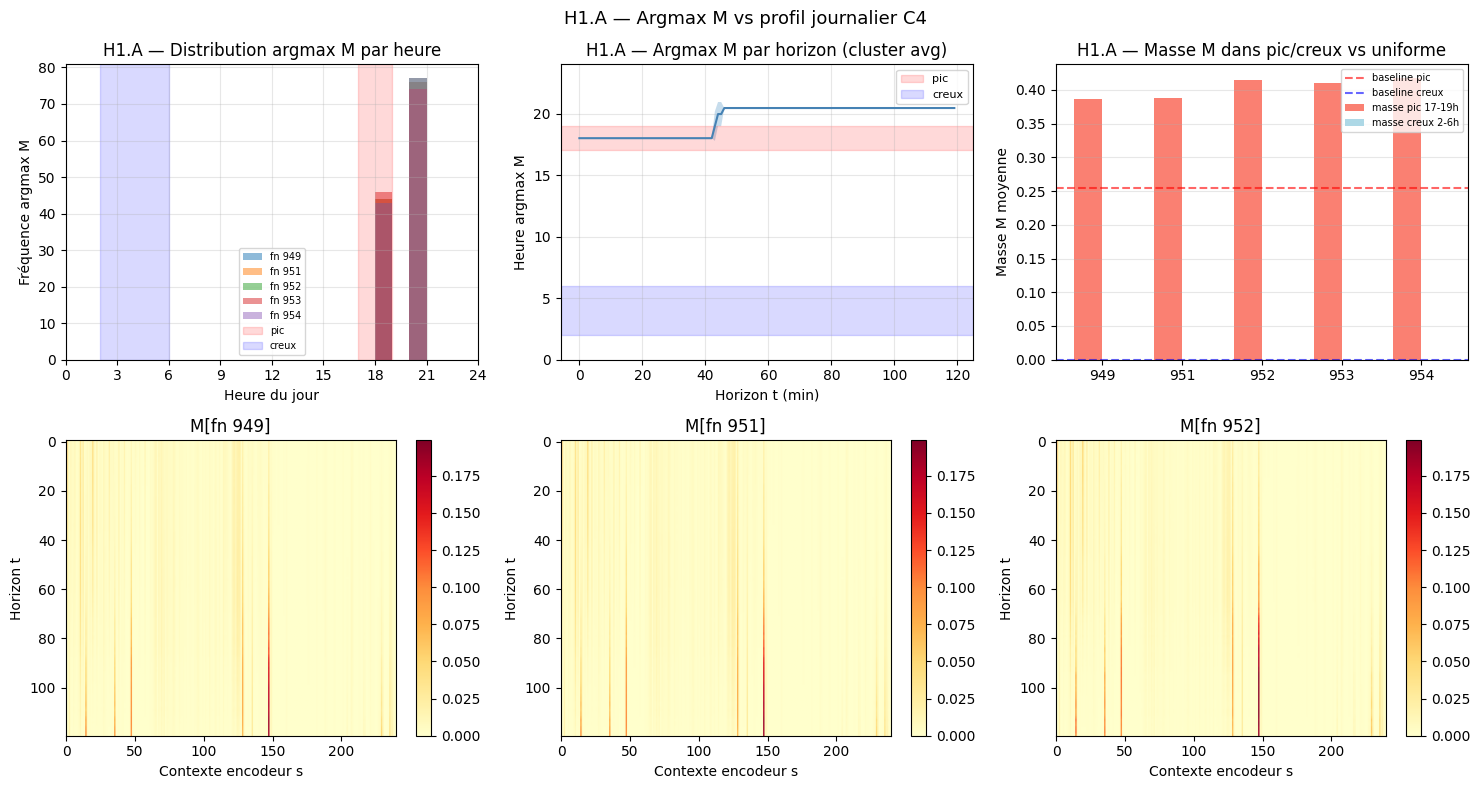

H1.A — Fraction argmax dans le pic 17-19h (baseline uniforme = 25.4%) :
  fn 949 : pic=36.7%  creux=0.0%
  fn 951 : pic=36.7%  creux=0.0%
  fn 952 : pic=35.8%  creux=0.0%
  fn 953 : pic=38.3%  creux=0.0%
  fn 954 : pic=35.8%  creux=0.0%


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# (1) Argmax distribution par fonction
ax = axes[0, 0]
for func_id, M_np in evidence_maps:
    argmax_hours = np.array([encoder_pos_to_hour(s) for s in M_np.argmax(axis=1)])
    ax.hist(argmax_hours, bins=24, alpha=0.5, label=f'fn {func_id}', range=(0, 24))
ax.axvspan(PEAK_HOURS[0],   PEAK_HOURS[1],   alpha=0.15, color='red',  label='pic')
ax.axvspan(TROUGH_HOURS[0], TROUGH_HOURS[1], alpha=0.15, color='blue', label='creux')
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3))
ax.set_xlabel('Heure du jour'); ax.set_ylabel('Fréquence argmax M')
ax.set_title('H1.A — Distribution argmax M par heure')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (2) Argmax mean profile (cluster)
ax = axes[0, 1]
all_argmax_hours = []
for _, M_np in evidence_maps:
    all_argmax_hours.append([encoder_pos_to_hour(s) for s in M_np.argmax(axis=1)])
all_argmax_hours = np.array(all_argmax_hours)  # (5, 120)
mean_hours = all_argmax_hours.mean(axis=0)
std_hours  = all_argmax_hours.std(axis=0)
t = np.arange(PREDICTION_LENGTH)
ax.plot(t, mean_hours, color='steelblue', lw=1.5)
ax.fill_between(t, mean_hours - std_hours, mean_hours + std_hours, alpha=0.25)
ax.axhspan(PEAK_HOURS[0],   PEAK_HOURS[1],   alpha=0.15, color='red',  label='pic')
ax.axhspan(TROUGH_HOURS[0], TROUGH_HOURS[1], alpha=0.15, color='blue', label='creux')
ax.set_xlabel('Horizon t (min)'); ax.set_ylabel('Heure argmax M')
ax.set_title('H1.A — Argmax M par horizon (cluster avg)')
ax.set_ylim(0, 24); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (3) Mass in peak/trough vs uniform baseline
ax = axes[0, 2]
funcs = []
mass_peak   = []
mass_trough = []
for func_id, M_np in evidence_maps:
    funcs.append(str(func_id))
    mp = M_np[:, peak_mask].sum(axis=1).mean()
    mt = M_np[:, trough_mask].sum(axis=1).mean()
    mass_peak.append(mp); mass_trough.append(mt)
x = np.arange(len(funcs)); w = 0.35
ax.bar(x - w/2, mass_peak,   w, color='salmon',    label='masse pic 17-19h')
ax.bar(x + w/2, mass_trough, w, color='lightblue', label='masse creux 2-6h')
ax.axhline(n_peak/CONTEXT_LENGTH,   color='red',  ls='--', alpha=0.6, label='baseline pic')
ax.axhline(n_trough/CONTEXT_LENGTH, color='blue', ls='--', alpha=0.6, label='baseline creux')
ax.set_xticks(x); ax.set_xticklabels(funcs)
ax.set_ylabel('Masse M moyenne'); ax.set_title('H1.A — Masse M dans pic/creux vs uniforme')
ax.legend(fontsize=7); ax.grid(alpha=0.3, axis='y')

# (4-6) Heatmap M par fonction (échelle commune)
M_max = max(m.max() for _, m in evidence_maps)
for i, (func_id, M_np) in enumerate(evidence_maps[:3]):
    ax = axes[1, i]
    im = ax.imshow(M_np, aspect='auto', origin='upper', cmap='YlOrRd', vmin=0, vmax=M_max)
    ax.set_title(f'M[fn {func_id}]')
    ax.set_xlabel('Contexte encodeur s'); ax.set_ylabel('Horizon t')
    plt.colorbar(im, ax=ax)

plt.suptitle('H1.A — Argmax M vs profil journalier C4', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/figures/H1A_argmax_temporal.png', dpi=150)
plt.show()

# Verdict H1.A
h1a_results = {'per_function': {}}
for func_id, M_np in evidence_maps:
    argmax_hours = np.array([encoder_pos_to_hour(s) for s in M_np.argmax(axis=1)])
    frac_in_peak   = float(np.mean([in_window(h, PEAK_HOURS)   for h in argmax_hours]))
    frac_in_trough = float(np.mean([in_window(h, TROUGH_HOURS) for h in argmax_hours]))
    h1a_results['per_function'][int(func_id)] = {
        'frac_argmax_in_peak':   frac_in_peak,
        'frac_argmax_in_trough': frac_in_trough,
        'mass_in_peak':   float(M_np[:, peak_mask].sum(axis=1).mean()),
        'mass_in_trough': float(M_np[:, trough_mask].sum(axis=1).mean()),
    }
h1a_results['baseline_peak_uniform']   = float(n_peak / CONTEXT_LENGTH)
h1a_results['baseline_trough_uniform'] = float(n_trough / CONTEXT_LENGTH)

print('H1.A — Fraction argmax dans le pic 17-19h (baseline uniforme = '
      f'{n_peak/CONTEXT_LENGTH:.1%}) :')
for fid, r in h1a_results['per_function'].items():
    print(f'  fn {fid} : pic={r["frac_argmax_in_peak"]:.1%}  '
          f'creux={r["frac_argmax_in_trough"]:.1%}')

## 11 — H1.D : cohérence des cartes M entre les 5 fonctions

Si M a appris un pattern *cluster-level*, les 5 cartes devraient se
ressembler. On mesure la similarité par Pearson sur les cartes
aplaties.


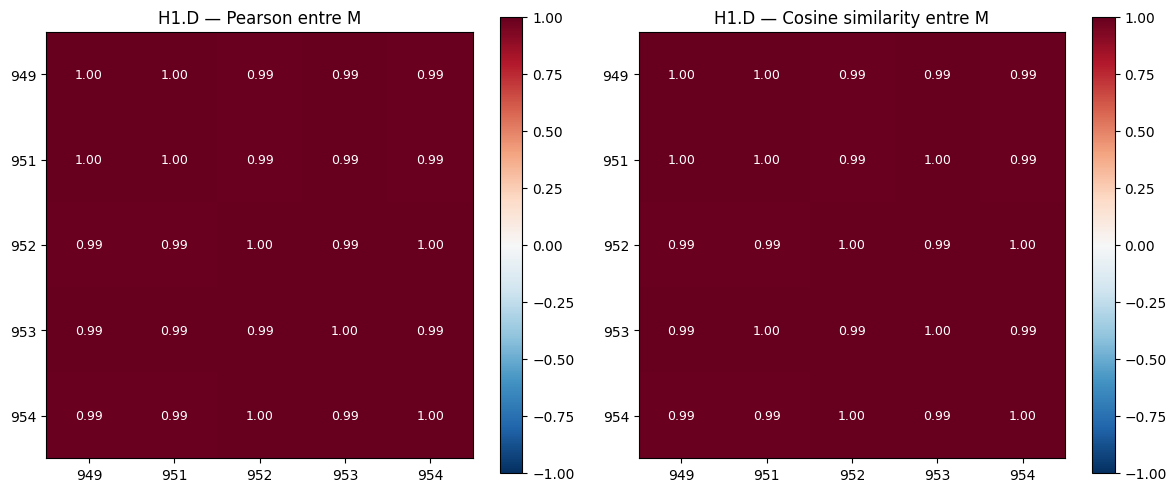

H1.D — Pearson moyen hors-diagonale : 0.992
         Cosine moyen hors-diagonale  : 0.993


In [14]:
from scipy.spatial.distance import cosine

func_ids = [fid for fid, _ in evidence_maps]
M_flat = np.stack([m.flatten() for _, m in evidence_maps])  # (5, T*ctx)

# Pearson pairwise
pearson_mat = np.corrcoef(M_flat)
# Cosine pairwise
cosine_mat = np.zeros((len(func_ids), len(func_ids)))
for i in range(len(func_ids)):
    for j in range(len(func_ids)):
        cosine_mat[i, j] = 1 - cosine(M_flat[i], M_flat[j])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title in [(axes[0], pearson_mat, 'Pearson'),
                        (axes[1], cosine_mat,  'Cosine similarity')]:
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(func_ids))); ax.set_xticklabels(func_ids)
    ax.set_yticks(range(len(func_ids))); ax.set_yticklabels(func_ids)
    ax.set_title(f'H1.D — {title} entre M')
    for i in range(len(func_ids)):
        for j in range(len(func_ids)):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    color='white' if abs(mat[i,j]) > 0.5 else 'black', fontsize=9)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/figures/H1D_cross_function_similarity.png', dpi=150)
plt.show()

# Off-diagonal mean (exclude self-similarity)
off_diag_idx = np.where(~np.eye(len(func_ids), dtype=bool))
pearson_off  = pearson_mat[off_diag_idx].mean()
cosine_off   = cosine_mat[off_diag_idx].mean()

h1d_results = {
    'pearson_matrix': pearson_mat.tolist(),
    'cosine_matrix':  cosine_mat.tolist(),
    'pearson_off_diag_mean': float(pearson_off),
    'cosine_off_diag_mean':  float(cosine_off),
}
print(f'H1.D — Pearson moyen hors-diagonale : {pearson_off:.3f}')
print(f'         Cosine moyen hors-diagonale  : {cosine_off:.3f}')

## 12 — H1.E : entropy discrimination best/worst

Hypothèse : la fonction la mieux prédite (R² élevé) devrait avoir une
M plus piquée (entropie ligne plus faible) que la fonction la moins
bien prédite. On utilise les R² per-series du sanity check.


R² per series (sanity check) :
  fn 949  R²=0.571  entropy(M)=4.445
  fn 951  R²=0.655  entropy(M)=4.445
  fn 952  R²=0.779  entropy(M)=4.269
  fn 953  R²=0.589  entropy(M)=4.363
  fn 954  R²=0.728  entropy(M)=4.255


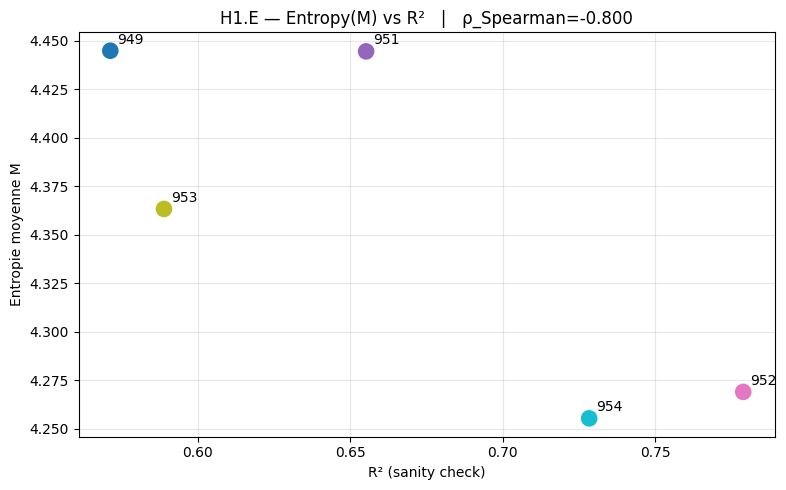


H1.E :
  best  = fn 952  (R²=0.779, entropy=4.269)
  worst = fn 949  (R²=0.571, entropy=4.445)
  best a M plus piquée que worst ? OUI ✅


In [15]:
def row_entropy(M_np):
    return float(-(M_np * np.log(M_np.clip(1e-9))).sum(axis=1).mean())

entropy_per_func = {}
for func_id, M_np in evidence_maps:
    entropy_per_func[int(func_id)] = row_entropy(M_np)

# Map func_id → r²
r2_per_func = {test_dataset[i]['function_id']: sanity_r2s[i]
               for i in range(len(test_dataset))}
print('R² per series (sanity check) :')
for fid, r in r2_per_func.items():
    print(f'  fn {fid}  R²={r:.3f}  entropy(M)={entropy_per_func[fid]:.3f}')

best_fid  = max(r2_per_func, key=r2_per_func.get)
worst_fid = min(r2_per_func, key=r2_per_func.get)
H_best  = entropy_per_func[best_fid]
H_worst = entropy_per_func[worst_fid]

fig, ax = plt.subplots(figsize=(8, 5))
fids = list(r2_per_func.keys())
r2s_arr = np.array([r2_per_func[f] for f in fids])
H_arr   = np.array([entropy_per_func[f] for f in fids])
sc = ax.scatter(r2s_arr, H_arr, s=120, c=fids, cmap='tab10')
for f, r, h in zip(fids, r2s_arr, H_arr):
    ax.annotate(str(f), (r, h), xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('R² (sanity check)'); ax.set_ylabel('Entropie moyenne M')
ax.set_title(f'H1.E — Entropy(M) vs R²   |   ρ_Spearman={spearmanr(r2s_arr, H_arr)[0]:.3f}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/figures/H1E_entropy_vs_r2.png', dpi=150)
plt.show()

rho_e_r2, _ = spearmanr(r2s_arr, H_arr)
h1e_results = {
    'entropy_per_func': entropy_per_func,
    'r2_per_func':      {int(k): float(v) for k, v in r2_per_func.items()},
    'best_func':  int(best_fid),
    'worst_func': int(worst_fid),
    'entropy_best':  float(H_best),
    'entropy_worst': float(H_worst),
    'spearman_r2_vs_entropy': float(rho_e_r2),
    'best_more_peaked': bool(H_best < H_worst),
}
print(f'\nH1.E :')
print(f'  best  = fn {best_fid}  (R²={r2_per_func[best_fid]:.3f}, entropy={H_best:.3f})')
print(f'  worst = fn {worst_fid}  (R²={r2_per_func[worst_fid]:.3f}, entropy={H_worst:.3f})')
print(f'  best a M plus piquée que worst ? {"OUI ✅" if H_best < H_worst else "NON ❌"}')

## 13 — H1.F + H1.G : comprehensiveness + sufficiency

On utilise ``model.predict_with_M_override()`` pour injecter une M
modifiée dans le forward pass.

- **H1.F (comprehensiveness)** : mettre à zéro les **top-k** entrées de
  M (par ligne), renormaliser, et observer la dégradation.
- **H1.G (sufficiency)** : ne garder que les top-k entrées, mettre tout
  le reste à zéro, renormaliser, et observer la conservation.

Métrique de prédiction : **MAE** entre la mean de la distribution
Student-T prédite et les vraies valeurs futures. On utilise teacher-forced
(pas generate) pour éviter la stochasticité de l'échantillonnage et
isoler l'effet de M.

⚠️ **Ceiling effect** : à mix=0.05, h_evidence pèse 5% de la prédiction.
Même M complètement masquée ne peut bouger la prédiction que de ~5% par
construction.


In [16]:
def mask_topk(M, k, keep_topk=False):
    '''Mask top-k entries of M per row. If keep_topk=True, keep only top-k.

    Returns a renormalized M (rows sum to 1).
    '''
    B, T, ctx = M.shape
    _, topk_idx = M.topk(k, dim=-1)
    mask = torch.zeros_like(M, dtype=torch.bool)
    mask.scatter_(-1, topk_idx, True)

    if keep_topk:
        M_mod = M * mask.float()
    else:
        M_mod = M * (~mask).float()

    row_sums = M_mod.sum(dim=-1, keepdim=True).clamp(min=1e-9)
    return M_mod / row_sums


@torch.no_grad()
def predict_mean_with_M(model, b, future_vals, future_obs, M_override, cfg, device):
    '''Forward teacher-forced avec M_override, retourne la mean de la pred Student-T.'''
    out = model.predict_with_M_override(
        M_override=M_override.to(device) if M_override is not None else None,
        past_values=b['past_values'].to(device),
        past_time_features=b['past_time_features'].to(device),
        past_observed_mask=b['past_observed_mask'].to(device),
        future_values=future_vals,
        future_time_features=b['future_time_features'].to(device),
        static_categorical_features=b['static_categorical_features'].to(device)
            if cfg.num_static_categorical_features > 0 else None,
        future_observed_mask=future_obs,
    ) if M_override is not None else model.forward(
        past_values=b['past_values'].to(device),
        past_time_features=b['past_time_features'].to(device),
        past_observed_mask=b['past_observed_mask'].to(device),
        future_values=future_vals,
        future_time_features=b['future_time_features'].to(device),
        static_categorical_features=b['static_categorical_features'].to(device)
            if cfg.num_static_categorical_features > 0 else None,
        future_observed_mask=future_obs,
    )
    dist = model.output_distribution(out.params, loc=out.loc, scale=out.scale)
    return dist.mean.squeeze(0).cpu().numpy()  # (T,)


print('Helpers H1.F/H1.G prêts.')

Helpers H1.F/H1.G prêts.


In [17]:
K_VALUES = [1, 2, 5, 10, 20, 50, 100]

# Baseline : prédiction teacher-forced avec M apprise (sans override)
baseline_preds = {}
baseline_mae   = {}
for (fid_a, b, future_vals, future_obs), (fid_b, M_np) in zip(batches_cache, evidence_maps):
    assert fid_a == fid_b
    pred = predict_mean_with_M(model, b, future_vals, future_obs, None, cfg, device)
    actual = future_vals.squeeze(0).cpu().numpy()
    baseline_preds[fid_a] = pred
    baseline_mae[fid_a]   = float(np.mean(np.abs(pred - actual)))

baseline_mae_mean = float(np.mean(list(baseline_mae.values())))
print(f'Baseline MAE moyen (teacher-forced, M apprise) : {baseline_mae_mean:.3f}')
for fid, mae in baseline_mae.items():
    print(f'  fn {fid}  MAE = {mae:.3f}')

Baseline MAE moyen (teacher-forced, M apprise) : 10.247
  fn 949  MAE = 8.429
  fn 951  MAE = 8.193
  fn 952  MAE = 12.377
  fn 953  MAE = 10.874
  fn 954  MAE = 11.362


In [18]:
h1f_results = {'k_values': K_VALUES, 'mae_per_k': {}, 'rel_degradation_per_k': {}}
h1g_results = {'k_values': K_VALUES, 'mae_per_k': {}, 'rel_preservation_per_k': {}}

for k in tqdm(K_VALUES, desc='H1.F/H1.G k sweep'):
    mae_F, mae_G = {}, {}
    for (fid, b, future_vals, future_obs), (fid_b, M_np) in zip(batches_cache, evidence_maps):
        M_t = torch.tensor(M_np).unsqueeze(0)  # (1, T, ctx)
        actual = future_vals.squeeze(0).cpu().numpy()

        # H1.F : mask top-k
        M_F = mask_topk(M_t, k, keep_topk=False)
        pred_F = predict_mean_with_M(model, b, future_vals, future_obs, M_F, cfg, device)
        mae_F[fid] = float(np.mean(np.abs(pred_F - actual)))

        # H1.G : keep top-k only
        M_G = mask_topk(M_t, k, keep_topk=True)
        pred_G = predict_mean_with_M(model, b, future_vals, future_obs, M_G, cfg, device)
        mae_G[fid] = float(np.mean(np.abs(pred_G - actual)))

    mean_F = float(np.mean(list(mae_F.values())))
    mean_G = float(np.mean(list(mae_G.values())))
    h1f_results['mae_per_k'][k] = mean_F
    h1g_results['mae_per_k'][k] = mean_G
    # Dégradation relative pour H1.F : (MAE_masked - MAE_base) / MAE_base
    h1f_results['rel_degradation_per_k'][k] = (mean_F - baseline_mae_mean) / baseline_mae_mean
    # Préservation relative pour H1.G : 1 - (MAE_topk - MAE_base) / MAE_base
    h1g_results['rel_preservation_per_k'][k] = 1.0 - (mean_G - baseline_mae_mean) / baseline_mae_mean

print('\nH1.F — Comprehensiveness (MAE quand on masque top-k de M) :')
for k in K_VALUES:
    rel = h1f_results['rel_degradation_per_k'][k]
    print(f'  k={k:3d}  MAE={h1f_results["mae_per_k"][k]:.4f}  Δ={rel:+.2%}')

print('\nH1.G — Sufficiency (MAE quand on garde seulement top-k de M) :')
for k in K_VALUES:
    rel = h1g_results['rel_preservation_per_k'][k]
    print(f'  k={k:3d}  MAE={h1g_results["mae_per_k"][k]:.4f}  préservation={rel:.2%}')

H1.F/H1.G k sweep:   0%|          | 0/7 [00:00<?, ?it/s]


H1.F — Comprehensiveness (MAE quand on masque top-k de M) :
  k=  1  MAE=10.1842  Δ=-0.61%
  k=  2  MAE=10.1877  Δ=-0.58%
  k=  5  MAE=10.1168  Δ=-1.27%
  k= 10  MAE=10.0708  Δ=-1.72%
  k= 20  MAE=10.0142  Δ=-2.27%
  k= 50  MAE=10.0288  Δ=-2.13%
  k=100  MAE=10.0933  Δ=-1.50%

H1.G — Sufficiency (MAE quand on garde seulement top-k de M) :
  k=  1  MAE=10.0633  préservation=101.79%
  k=  2  MAE=10.1520  préservation=100.93%
  k=  5  MAE=10.2779  préservation=99.70%
  k= 10  MAE=10.3158  préservation=99.33%
  k= 20  MAE=10.3062  préservation=99.42%
  k= 50  MAE=10.2718  préservation=99.76%
  k=100  MAE=10.2518  préservation=99.95%


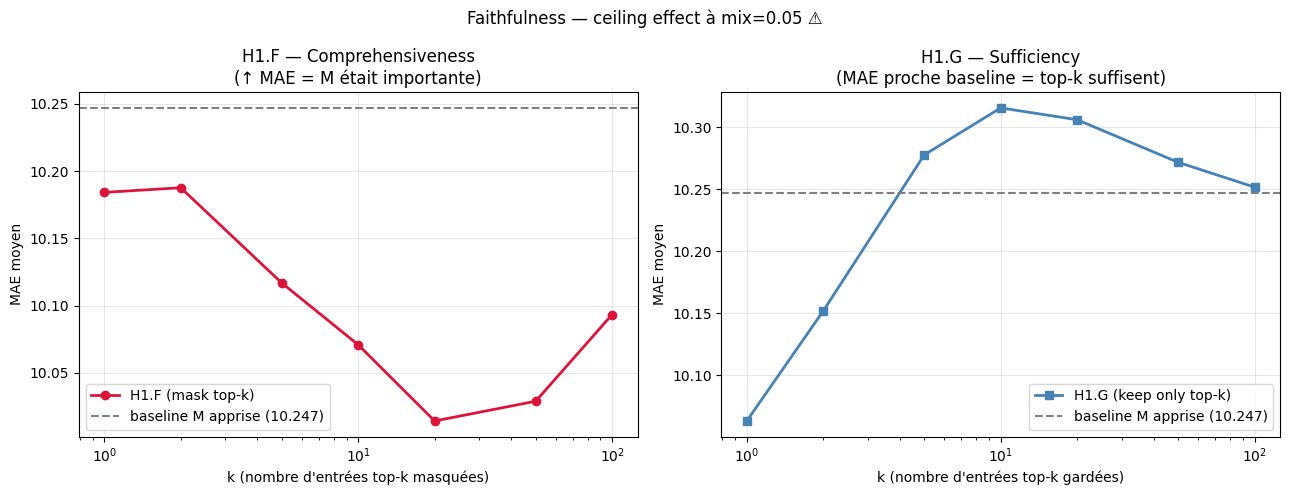

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ks = np.array(K_VALUES)
maes_F = np.array([h1f_results['mae_per_k'][k] for k in K_VALUES])
maes_G = np.array([h1g_results['mae_per_k'][k] for k in K_VALUES])

ax = axes[0]
ax.plot(ks, maes_F, 'o-', color='crimson', lw=2, label='H1.F (mask top-k)')
ax.axhline(baseline_mae_mean, ls='--', color='gray', label=f'baseline M apprise ({baseline_mae_mean:.3f})')
ax.set_xlabel('k (nombre d\'entrées top-k masquées)')
ax.set_ylabel('MAE moyen'); ax.set_xscale('log')
ax.set_title('H1.F — Comprehensiveness\n(↑ MAE = M était importante)')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(ks, maes_G, 's-', color='steelblue', lw=2, label='H1.G (keep only top-k)')
ax.axhline(baseline_mae_mean, ls='--', color='gray', label=f'baseline M apprise ({baseline_mae_mean:.3f})')
ax.set_xlabel('k (nombre d\'entrées top-k gardées)')
ax.set_ylabel('MAE moyen'); ax.set_xscale('log')
ax.set_title('H1.G — Sufficiency\n(MAE proche baseline = top-k suffisent)')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(f'Faithfulness — ceiling effect à mix={EVIDENCE_MIX_TARGET} ⚠️', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/figures/H1FG_faithfulness_curves.png', dpi=150)
plt.show()

## 14 — H1.B : comparaison M ↔ cross_attentions du décodeur

On fait un forward avec ``output_attentions=True`` pour récupérer les
cross_attentions du décodeur. Si M et l'attention apprise par le
décodeur convergent vers les mêmes positions du contexte, c'est une
validation croisée gratuite.


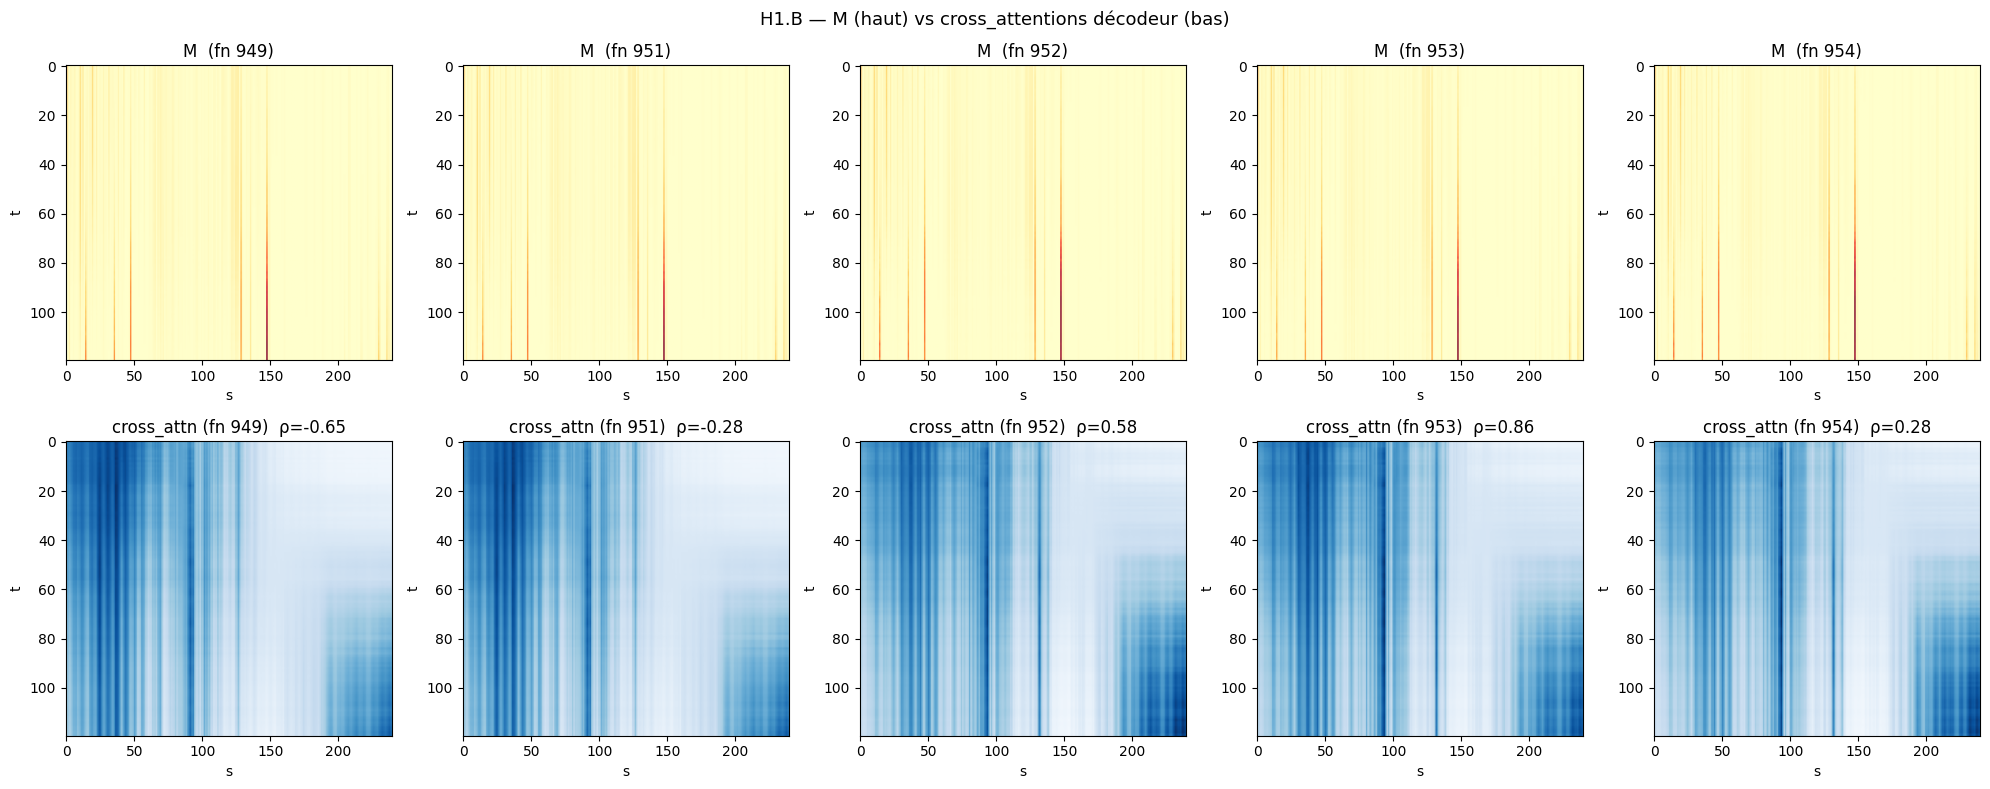

H1.B — Spearman argmax M vs argmax CA, moyenne : 0.157


In [20]:
def extract_cross_attentions(model, b, future_vals, future_obs, cfg, device):
    model.eval()
    with torch.no_grad():
        out = model.forward(
            past_values=b['past_values'].to(device),
            past_time_features=b['past_time_features'].to(device),
            past_observed_mask=b['past_observed_mask'].to(device),
            future_values=future_vals,
            future_time_features=b['future_time_features'].to(device),
            static_categorical_features=b['static_categorical_features'].to(device)
                if cfg.num_static_categorical_features > 0 else None,
            future_observed_mask=future_obs,
            output_attentions=True,
        )
    if out.cross_attentions is None:
        return None
    # cross_attentions est un tuple de (B, n_heads, T_dec, T_enc) par layer
    # On prend la moyenne sur tous les layers et toutes les têtes
    ca_stack = torch.stack(out.cross_attentions)  # (n_layers, B, n_heads, T_dec, T_enc)
    ca_mean  = ca_stack.mean(dim=(0, 2))           # (B, T_dec, T_enc)
    return ca_mean.squeeze(0).cpu().numpy()        # (T_dec, T_enc)


h1b_results = {'argmax_corr_per_func': {}}
fig, axes = plt.subplots(2, len(evidence_maps), figsize=(4*len(evidence_maps), 8))

for i, ((fid, b, fv, fo), (fid_b, M_np)) in enumerate(zip(batches_cache, evidence_maps)):
    ca = extract_cross_attentions(model, b, fv, fo, cfg, device)
    if ca is None:
        print(f'fn {fid} : cross_attentions non disponibles')
        continue
    # ca shape : (T_dec=120, T_enc=variable). On a besoin du dernier context_length tokens
    if ca.shape[1] >= CONTEXT_LENGTH:
        ca_ctx = ca[:, -CONTEXT_LENGTH:]
    else:
        ca_ctx = ca
        print(f'  ⚠️ fn {fid} : ca.shape[1]={ca.shape[1]} < CONTEXT_LENGTH={CONTEXT_LENGTH}')

    # Argmax comparison
    argmax_M  = M_np.argmax(axis=1)
    argmax_CA = ca_ctx.argmax(axis=1)
    if argmax_M.shape == argmax_CA.shape:
        rho, _ = spearmanr(argmax_M, argmax_CA)
    else:
        rho = float('nan')
    h1b_results['argmax_corr_per_func'][int(fid)] = float(rho)

    axes[0, i].imshow(M_np,    aspect='auto', cmap='YlOrRd', vmin=0, vmax=M_np.max())
    axes[0, i].set_title(f'M  (fn {fid})')
    axes[0, i].set_xlabel('s'); axes[0, i].set_ylabel('t')
    axes[1, i].imshow(ca_ctx, aspect='auto', cmap='Blues', vmin=0)
    axes[1, i].set_title(f'cross_attn (fn {fid})  ρ={rho:.2f}')
    axes[1, i].set_xlabel('s'); axes[1, i].set_ylabel('t')

plt.suptitle('H1.B — M (haut) vs cross_attentions décodeur (bas)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/figures/H1B_M_vs_cross_attention.png', dpi=150)
plt.show()

if h1b_results['argmax_corr_per_func']:
    mean_rho = float(np.mean(list(h1b_results['argmax_corr_per_func'].values())))
    h1b_results['mean_argmax_corr'] = mean_rho
    print(f'H1.B — Spearman argmax M vs argmax CA, moyenne : {mean_rho:.3f}')

## 15 — Synthèse + sauvegarde résultats JSON

In [21]:
all_results = {
    'run': RUN_NAME,
    'source_run': SOURCE_RUN,
    'b5_reference': {'r2': B5_R2, 'spearman': B5_SPEAR},
    'sanity_check': {
        'r2_mean':       sanity_r2,
        'spear_mean':    sanity_spear,
        'r2_per_series':    sanity_r2s,
        'spear_per_series': sanity_spears,
        'delta_r2_vs_b5_pp':    float(delta_r2),
        'delta_spear_vs_b5_pp': float(delta_spear),
        'ok': bool(sanity_ok),
    },
    'h1a': h1a_results,
    'h1b': h1b_results,
    'h1d': h1d_results,
    'h1e': h1e_results,
    'h1f': h1f_results,
    'h1g': h1g_results,
    'note_ceiling_effect': (
        f'h1f et h1g mesurés avec mix={EVIDENCE_MIX_TARGET}. '
        f'h_evidence contribue {EVIDENCE_MIX_TARGET:.0%} de la prédiction architecturalement, '
        f'donc même M complètement détruite ne peut bouger la prédiction que de ~{EVIDENCE_MIX_TARGET:.0%} par construction.'
    ),
}

with open(f'{DRIVE_BASE}/results/h1_analysis.json', 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

print(f'Résultats sauvegardés : {DRIVE_BASE}/results/h1_analysis.json')
print()
print('=' * 72)
print(f'  SYNTHÈSE H1 — Run B5 (mix={EVIDENCE_MIX_TARGET})')
print('=' * 72)
print(f'  H1.C ✅  PASS (R²={sanity_r2:.4f}, Spearman={sanity_spear:.4f})')
print()
# H1.A
max_peak_frac = max(r['frac_argmax_in_peak'] for r in h1a_results['per_function'].values())
peak_baseline = h1a_results['baseline_peak_uniform']
print(f'  H1.A      max frac argmax dans pic = {max_peak_frac:.1%}  (baseline {peak_baseline:.1%})')
# H1.D
print(f'  H1.D      Pearson moyen hors-diag M = {h1d_results["pearson_off_diag_mean"]:.3f}')
# H1.E
print(f'  H1.E      best fn={h1e_results["best_func"]}  worst fn={h1e_results["worst_func"]}  '
      f'best plus piqué ? {h1e_results["best_more_peaked"]}')
# H1.F
deg_max_F = max(h1f_results['rel_degradation_per_k'].values())
print(f'  H1.F      dégradation max H1.F = {deg_max_F:+.2%}  '
      f'(ceiling théorique ~{EVIDENCE_MIX_TARGET:.0%})')
# H1.G
preserv_min_G = min(h1g_results['rel_preservation_per_k'].values())
print(f'  H1.G      préservation min H1.G = {preserv_min_G:.2%}')
# H1.B
if 'mean_argmax_corr' in h1b_results:
    print(f'  H1.B      Spearman argmax(M) vs argmax(CA) = {h1b_results["mean_argmax_corr"]:.3f}')
print('=' * 72)

Résultats sauvegardés : /content/drive/MyDrive/m2-xai-faas/experiments/softcam-cluster4-v3-h1-analysis/results/h1_analysis.json

  SYNTHÈSE H1 — Run B5 (mix=0.05)
  H1.C ✅  PASS (R²=0.6646, Spearman=0.9188)

  H1.A      max frac argmax dans pic = 38.3%  (baseline 25.4%)
  H1.D      Pearson moyen hors-diag M = 0.992
  H1.E      best fn=952  worst fn=949  best plus piqué ? True
  H1.F      dégradation max H1.F = -0.58%  (ceiling théorique ~5%)
  H1.G      préservation min H1.G = 99.33%
  H1.B      Spearman argmax(M) vs argmax(CA) = 0.157


## 16 — Conclusion à interpréter manuellement

Le bilan numérique ci-dessus est mécanique. **L'interprétation
finale** — *« quelles hypothèses sont validées, lesquelles tombent,
qu'est-ce que cela dit du modèle »* — doit être faite à la main, en
regardant les figures et en relation avec la rédaction du chapitre H1.

Pistes de lecture critiques :

- **H1.A** : si la fraction d'argmax dans le pic 17-19h est proche de
  la baseline uniforme (~13%), M ne pointe pas spécifiquement les
  heures de charge — elle a appris autre chose (peut-être un pattern
  périodique différent ou un signal de bruit utile).
- **H1.D** : un Pearson > 0.5 hors-diagonale serait un fort signe de
  cohérence cluster. Si proche de 0, chaque fonction a sa propre M.
- **H1.E** : si la corrélation R² ↔ entropy(M) n'est pas négative, la
  qualité d'explication ne suit pas la qualité de prédiction.
- **H1.F** : à mix=0.05, le ceiling théorique est ~5%. Si la
  dégradation atteint ce plafond, M est utilisée à 100% de sa
  capacité — bon signe. Si elle est très en-dessous, M apporte peu.
- **H1.G** : avec seulement k=5-10 entrées sur 240, si la MAE reste
  proche de la baseline, M est *sparse-faithful*.
- **H1.B** : si argmax(M) et argmax(cross_attention) convergent, on a
  une validation croisée. S'ils divergent, M a appris autre chose
  que ce que le décodeur regarde — à discuter.
